In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import calculations as calc

In [89]:
def check_samples(population, sample_count, sample_size, sample_replace):
    
    choice = lambda x: np.random.choice(x, size=sample_size, replace=sample_replace)
    
    sample_means = [np.mean(choice(population)) for _ in range(sample_count)]
    sample_variances = [np.var(choice(population)) for _ in range(sample_count)]
    sample_stds = [np.std(choice(population)) for _ in range(sample_count)]
    
    df = pd.DataFrame({
        "mean":sample_means,  
        "variance": sample_variances,
        "std": sample_stds
    })
    
    df_melted = df.melt(var_name="metric", value_name="value")
    
    # Визуализация
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
    
    metrics = df_melted["metric"].unique()
    for i, metric in enumerate(metrics):
        subset = df_melted[df_melted["metric"] == metric]
        sns.histplot(data=subset, x="value", ax=axes[i], kde=True) 
        axes[i].set_title(metric)
        
    fig.suptitle(f"sample_count: {sample_count}, sample_size:{sample_size}", fontsize=16)
    plt.tight_layout()
    plt.show()

In [87]:
def show_charts(population):
    params = [
        {"sample_count": 1000, "sample_size": 2},
        {"sample_count": 1000, "sample_size": 10},
        {"sample_count": 1000, "sample_size": 35},
        {"sample_count": 1000, "sample_size": 100},
        {"sample_count": 1000, "sample_size": 1000}
    ]
    
    for param in params:
        check_samples(
            population=population,
            sample_count=param["sample_count"],
            sample_size=param["sample_size"],
            sample_replace=True
        )

## Нормальное распределение

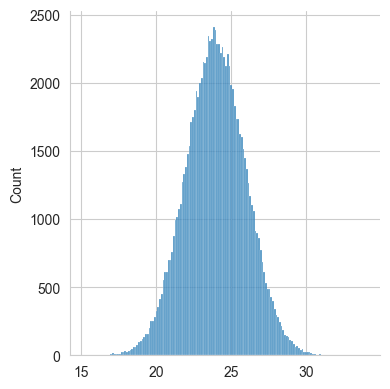

In [105]:
rng = np.random.default_rng(seed=42)
population_norm = rng.normal(size=100_000, loc=24, scale=2)
sns.displot(population_norm, height=4);

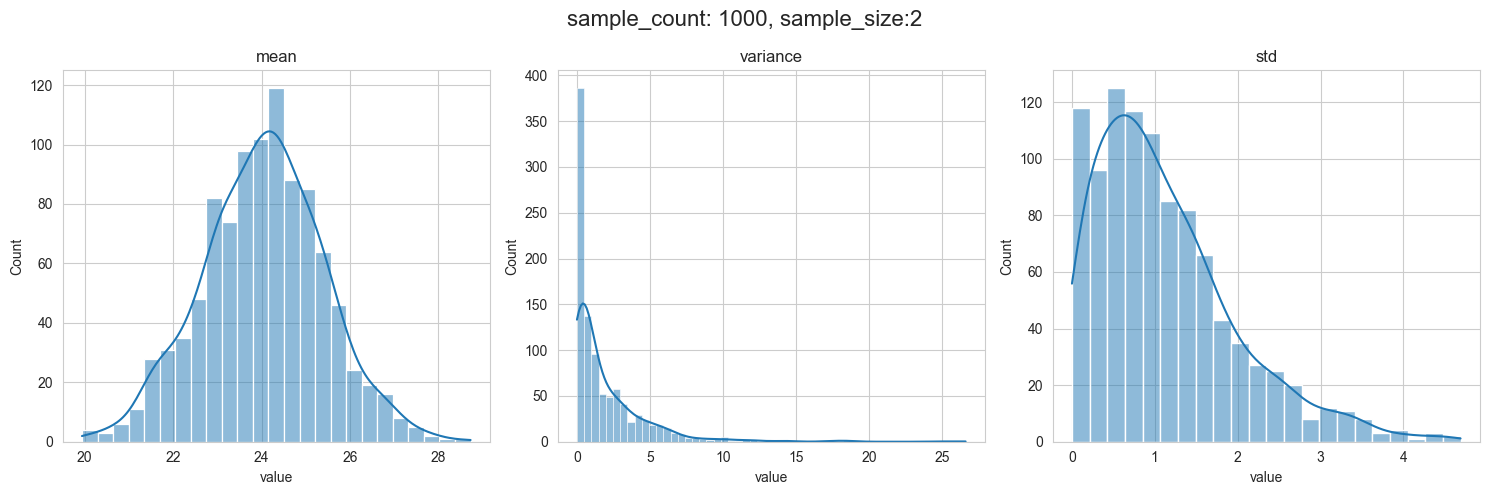

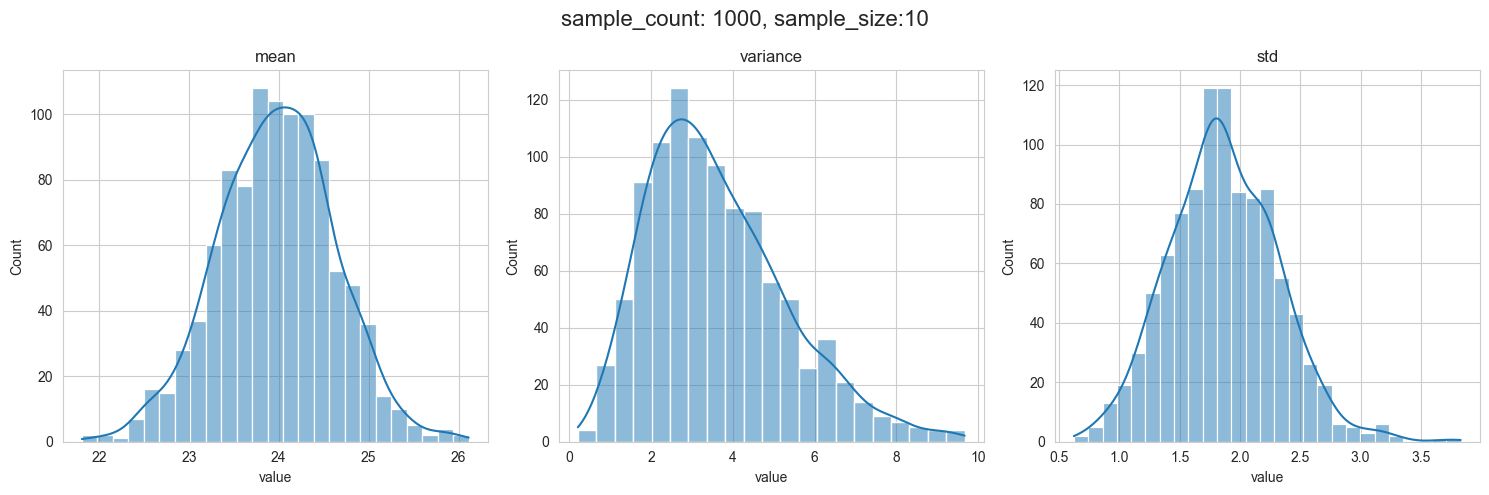

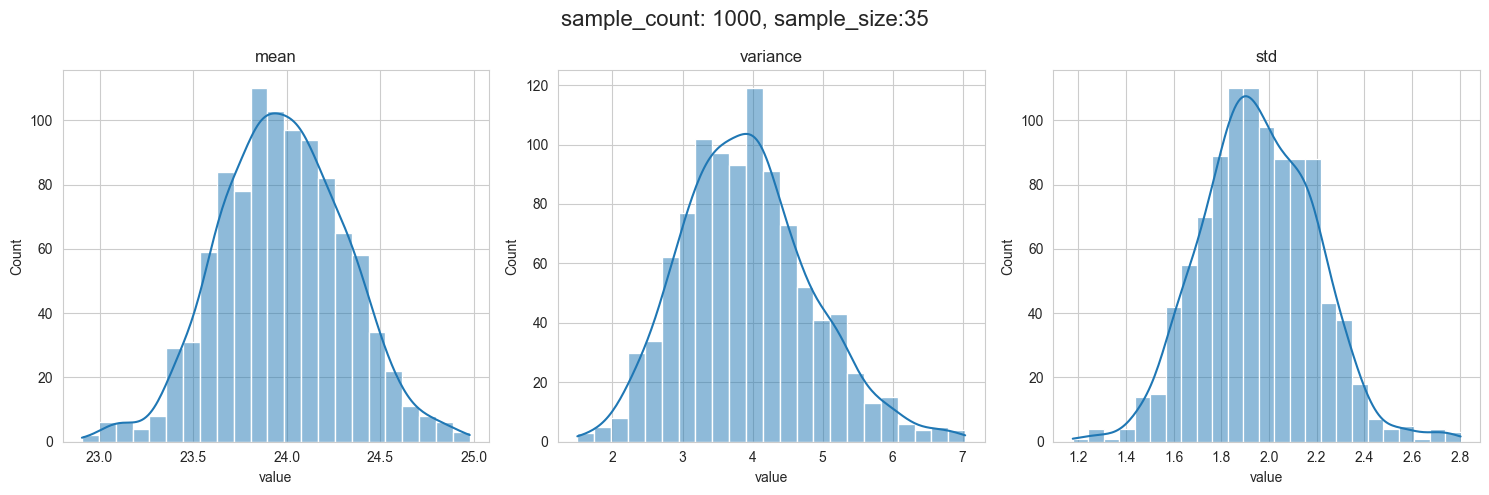

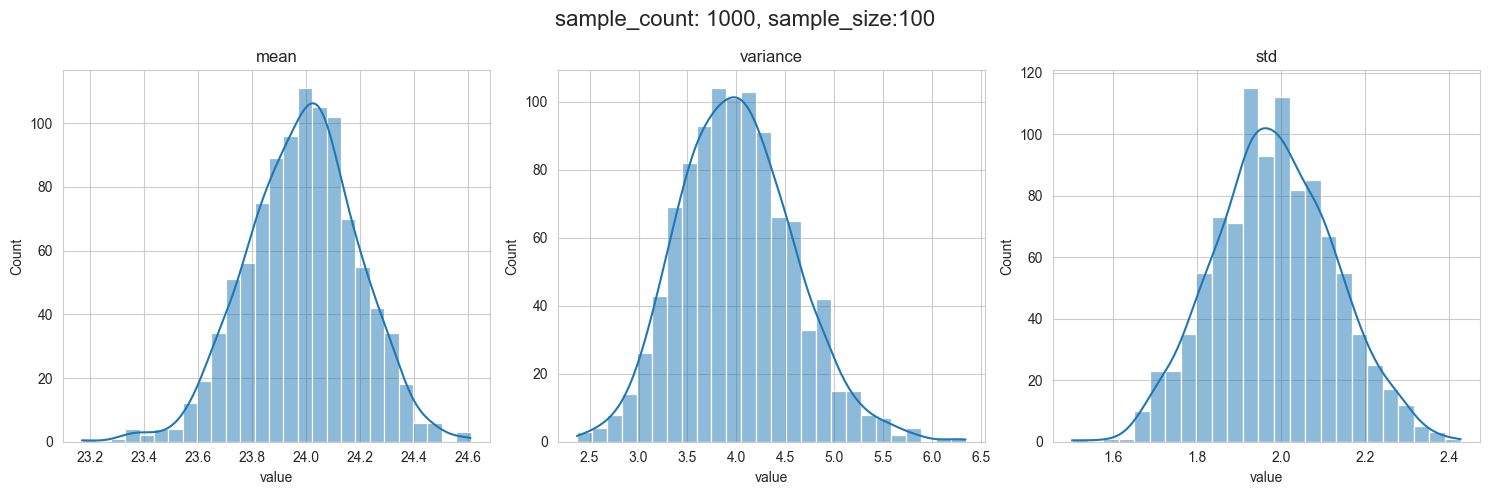

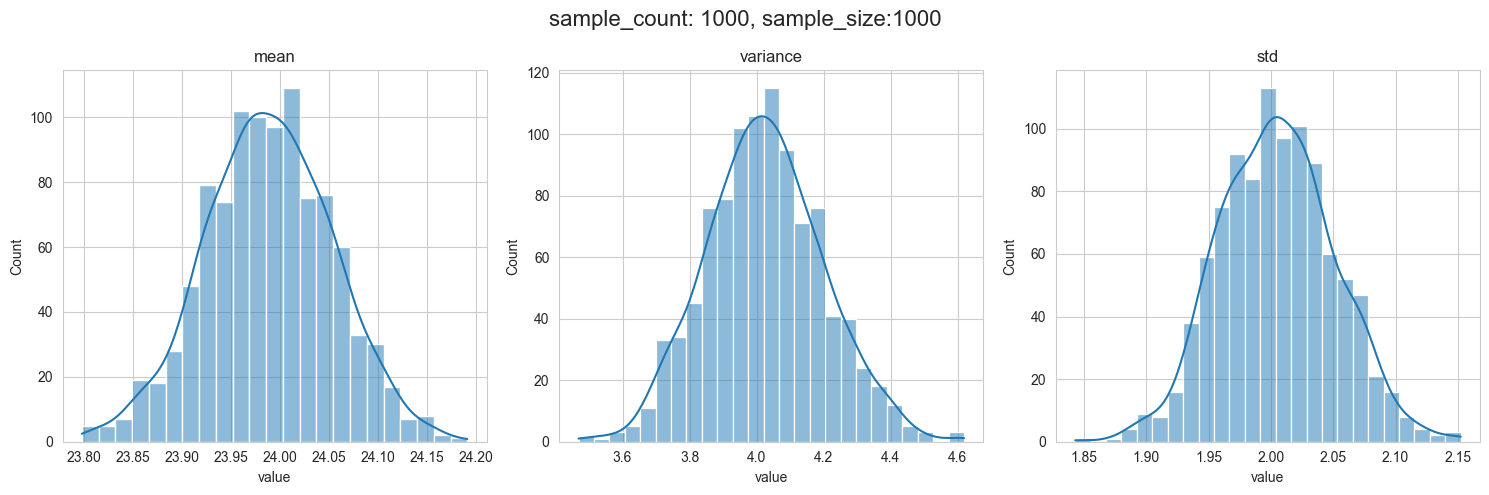

In [106]:
show_charts(population=population_norm)

## Экспоненциальное распределение 

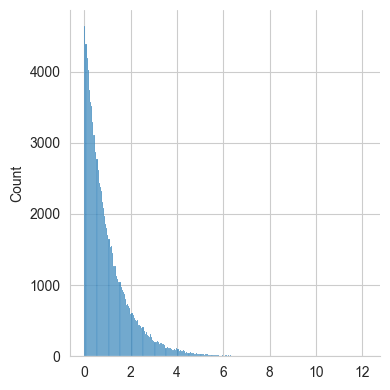

In [112]:
rng = np.random.default_rng(seed=42)
population_exp = rng.exponential(scale=1, size=100_000)
sns.displot(population_exp, height=4);

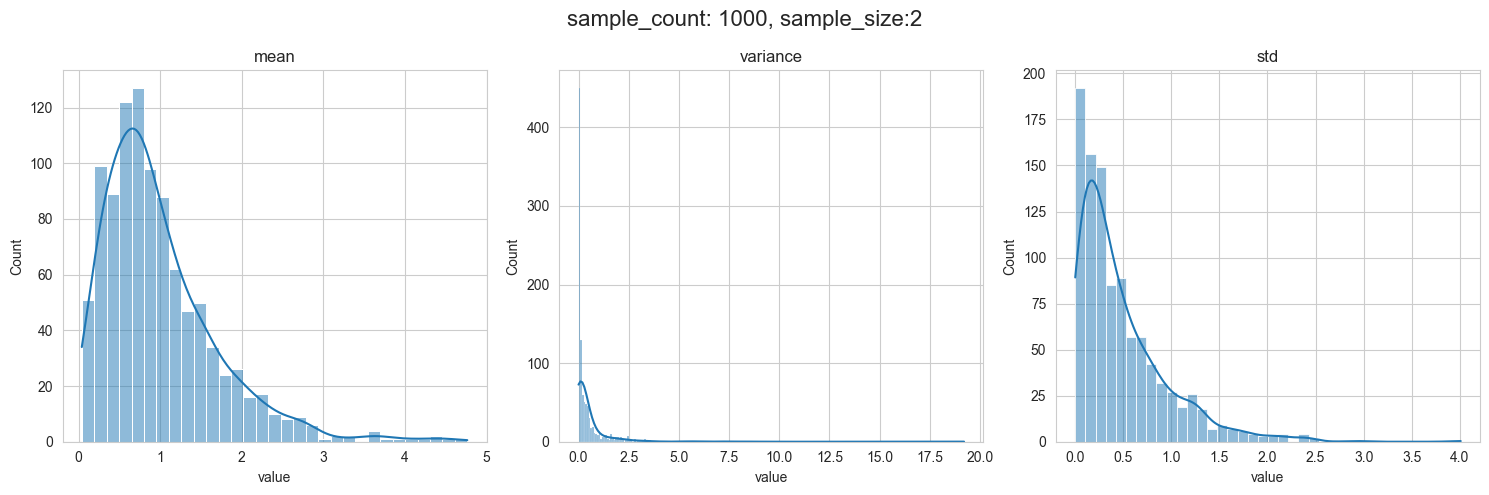

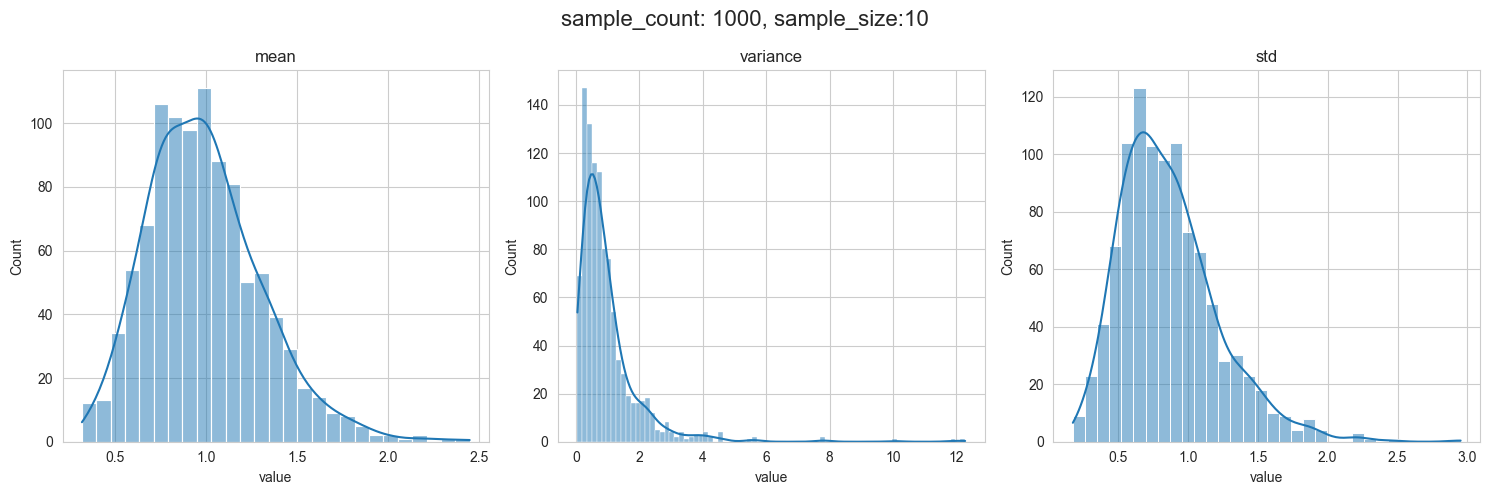

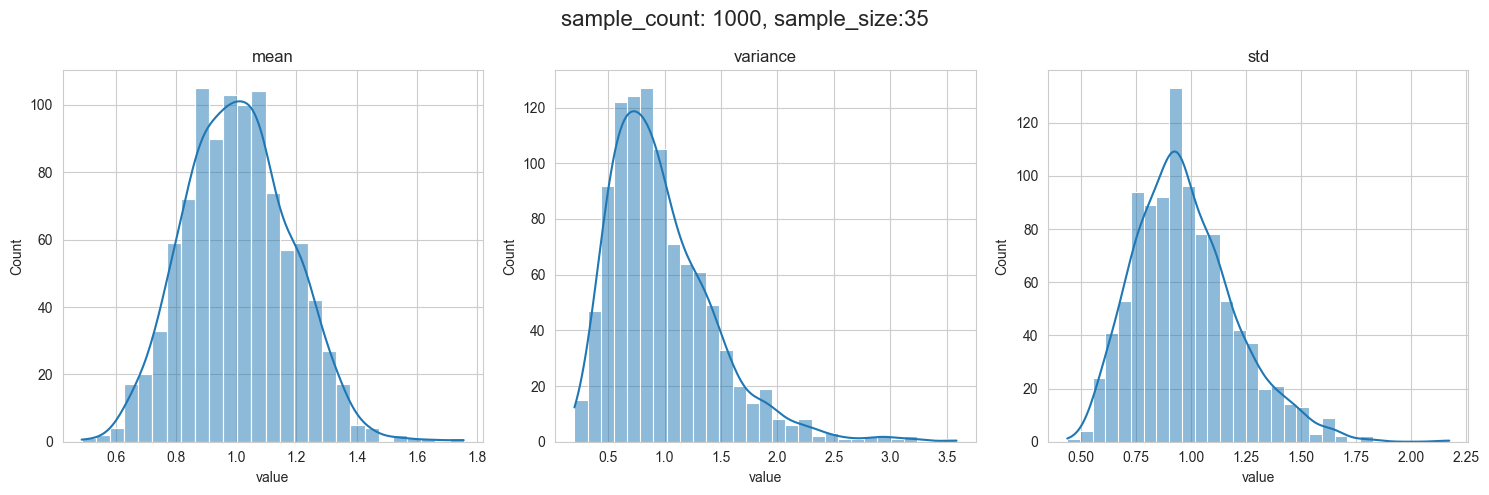

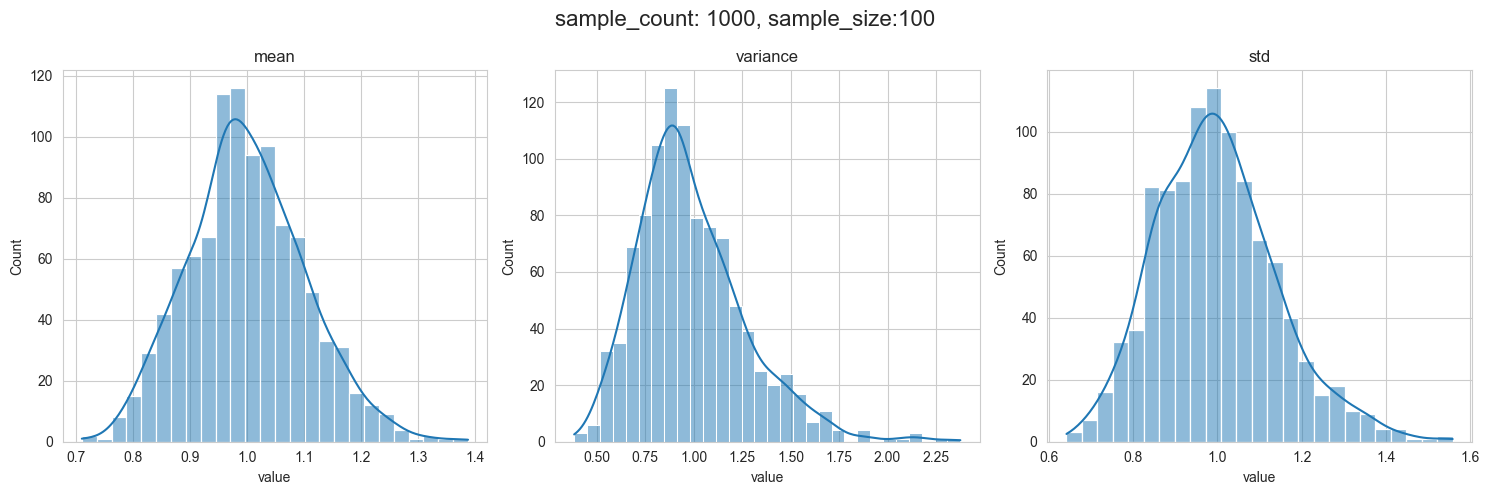

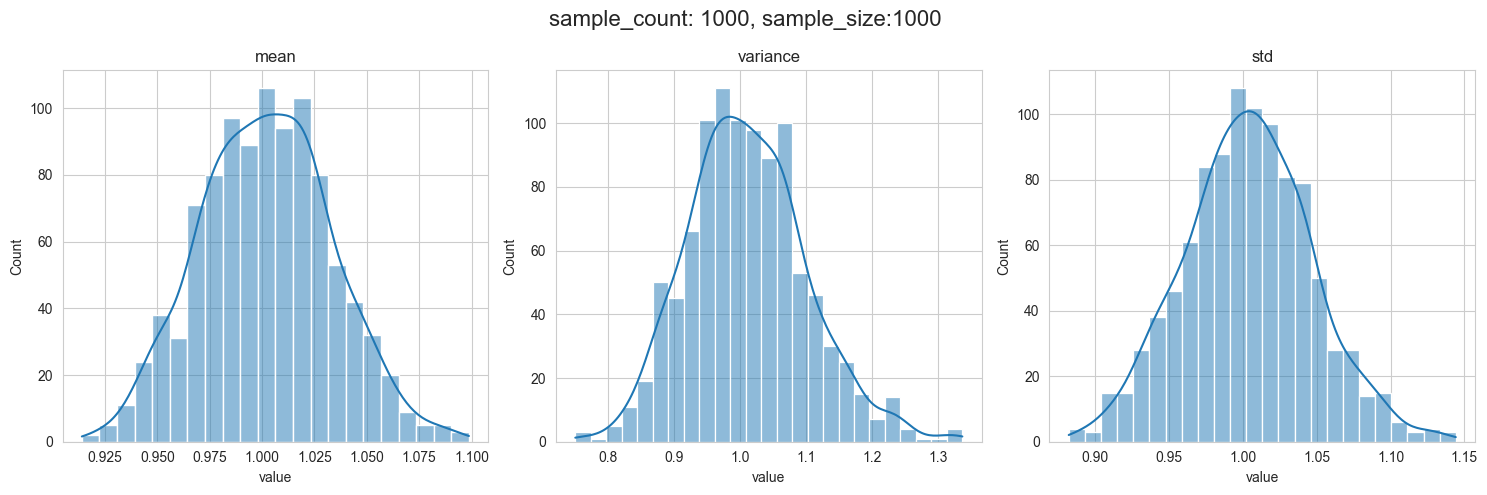

In [113]:
show_charts(population=population_exp)

## Равномерное распределение 

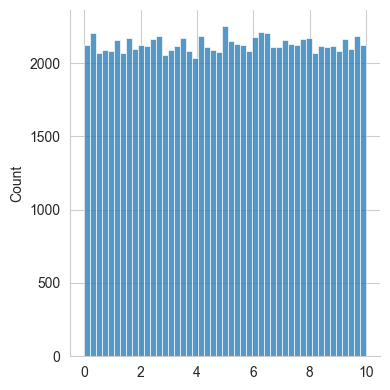

In [114]:
rng = np.random.default_rng(seed=42)
population_uniform = rng.uniform(low=0, high=10, size=100_000)
sns.displot(population_uniform, height=4);

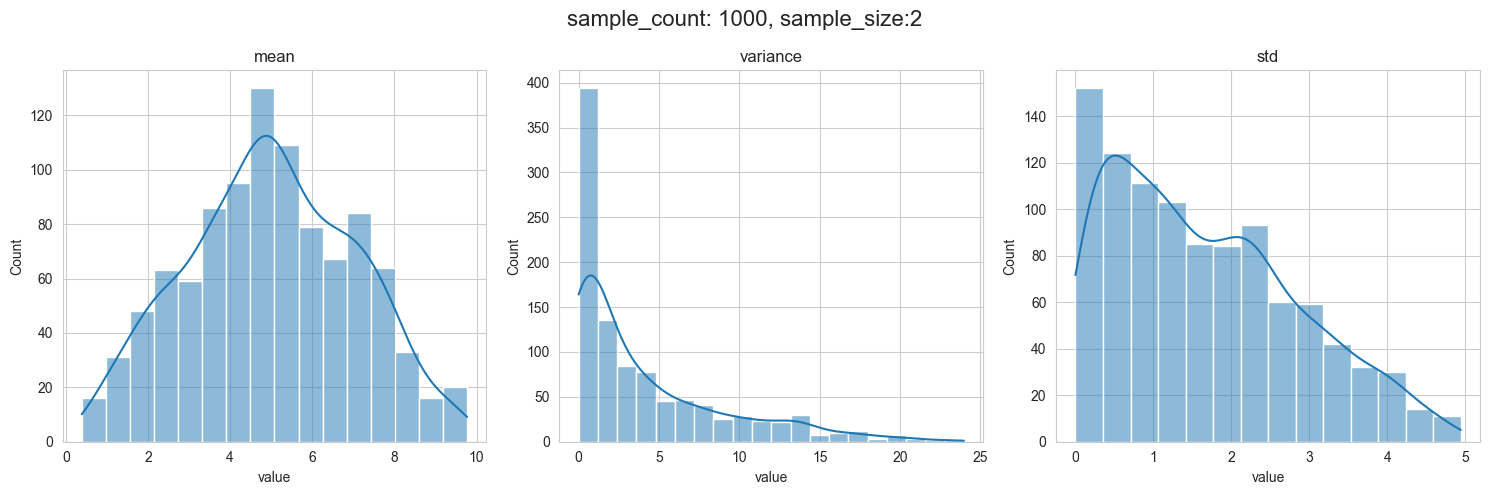

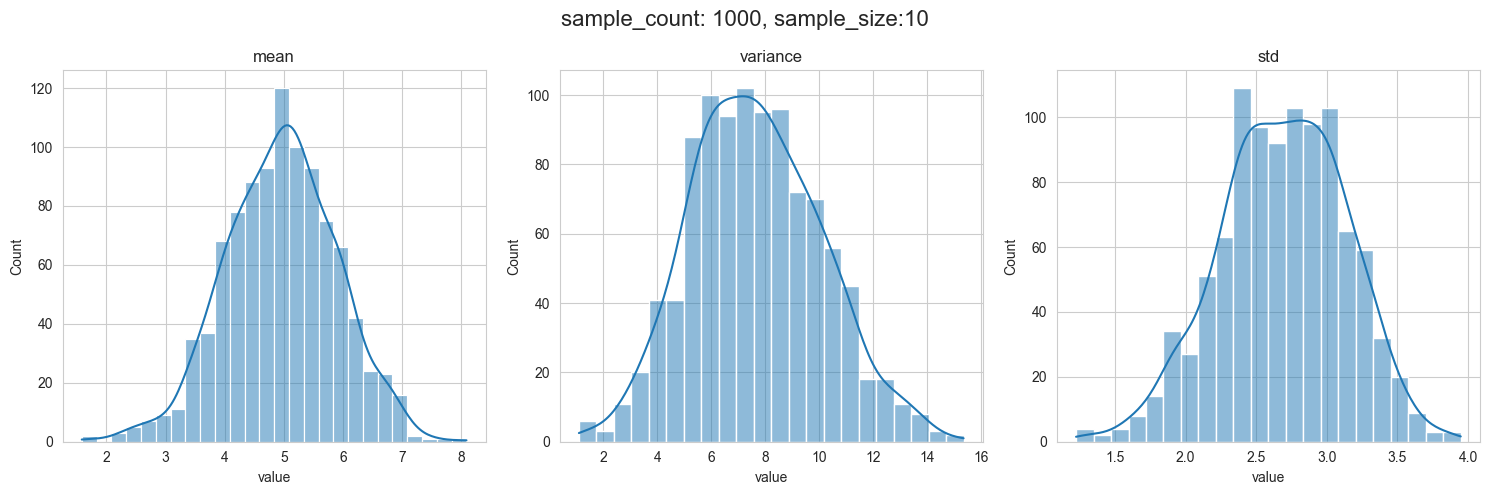

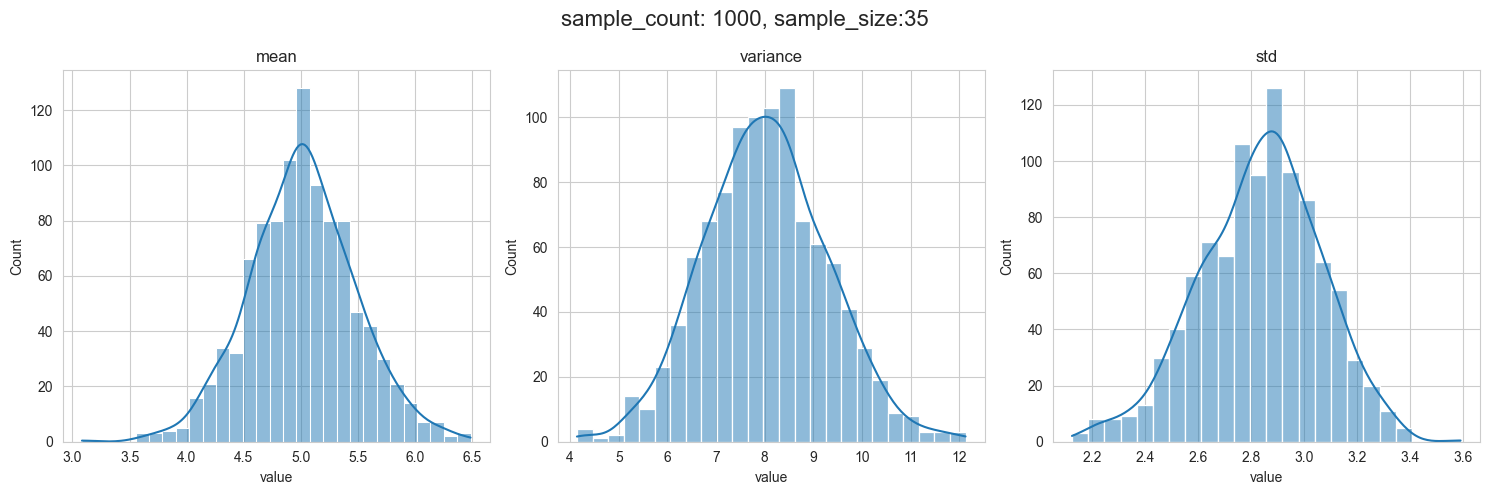

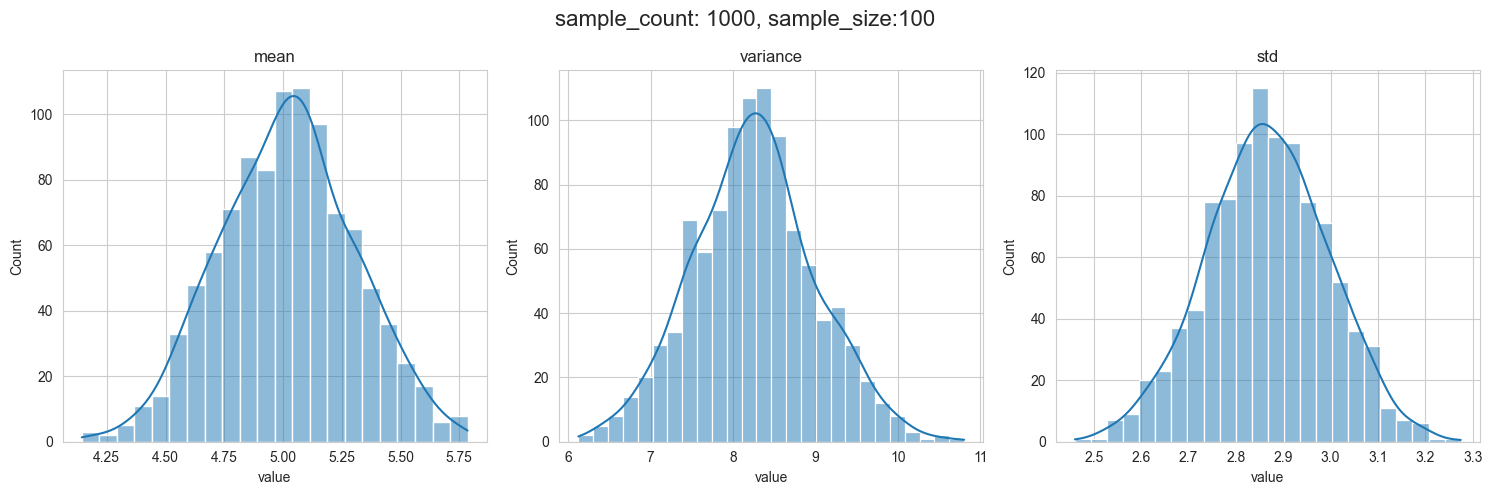

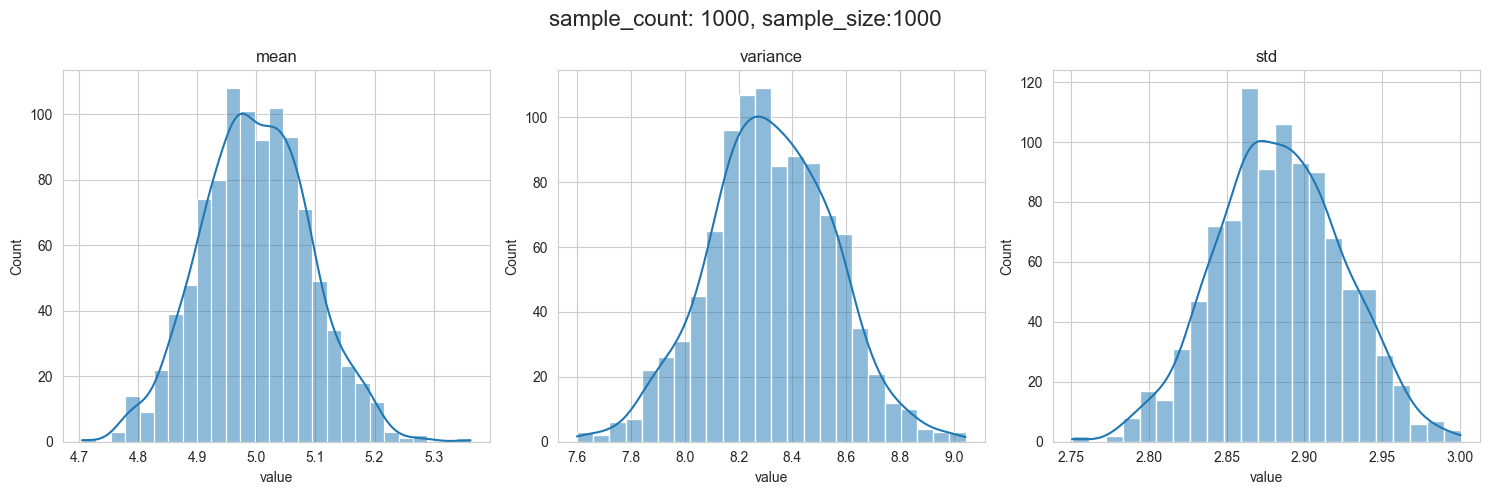

In [115]:
show_charts(population=population_uniform)